# Tutorial: Polars & Dataframely

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import polars as pl

## Task 1: Exploring the Raw Data

In [3]:
policies = pl.read_parquet("data/policies.parquet")
models = pl.read_parquet("data/models.parquet")

In [4]:
# TODO: Print data frames to explore their structure

In [5]:
policies

model,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density
str,str,f64,f64,f64,str,i64
"""M1080""","""policy6153536""",1.058001,29.806413,42.86828,"""C9""",17865
"""M791""","""policy6592089""",1.05291,12.161883,29.440503,"""C21""",3268
"""M880""","""policy2173464""",0.767566,31.490837,49.018794,"""C5""",34771
"""M868""","""policy8580874""",1.058158,4.127161,26.550939,"""C13""",5315
"""M652""","""policy9734033""",0.229067,0.0,19.016336,"""C5""",34758
…,…,…,…,…,…,…
"""M868""","""policy6461660""",0.822152,2.438748,48.125986,"""C17""",65716
"""M264""","""policy7367444""",0.511807,3.896717,19.012395,"""C8""",34763
"""M557""","""policy9228959""",0.488506,3.117143,33.291614,"""C1""",4959


In [6]:
models

model,segment,fuel_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,_model_age,engine_type,make,max_power,max_torque,_scale
str,str,str,i64,str,str,str,str,str,str,i64,i64,str,i64,str,f64,f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,u64,str,u64,str,str,f64
"""M53""","""Utility""","""Diesel""",1,"""No""","""Yes""","""No""","""Yes""","""Yes""","""Drum""",1186,3,"""Manual""",5,"""Power""",4.71,353.9448,159.9246,146.4848,1523,"""No""","""No""","""No""","""Yes""","""No""","""Yes""","""Yes""","""Yes""","""No""","""No""","""Yes""","""Yes""",4,49,"""1.5 L CRAIL Diesel""",6,"""91.9375bhp@5995rpm""","""128.0Nm@4311rpm""",0.0902
"""M915""","""Utility""","""CNG""",1,"""No""","""No""","""No""","""Yes""","""No""","""Drum""",1057,4,"""Automatic""",5,"""Power""",4.75,352.296,140.0796,150.8908,1504,"""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""Yes""","""No""","""No""","""Yes""","""Yes""",1,34,"""1.5 L DDiS 225""",0,"""59.40625bhp@5997rpm""","""86.7Nm@3897rpm""",0.0932
"""M655""","""B2""","""Petrol""",3,"""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Disc""",1498,4,"""Manual""",6,"""Electric""",5.2,4161.132,1760.292,1549.368,1661,"""No""","""No""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""No""","""Yes""","""Yes""",5,14,"""1.5 L K Series Petrol""",13,"""118.375bhp@3600rpm""","""250.0Nm@2790rpm""",0.972
"""M416""","""Utility""","""Diesel""",1,"""No""","""Yes""","""No""","""Yes""","""No""","""Disc""",1375,4,"""Manual""",5,"""Electric""",4.61,3497.392,1673.504,1429.612,1187,"""No""","""No""","""No""","""Yes""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""No""","""Yes""","""Yes""",5,18,"""1.1 L iRDE2""",3,"""100.125bhp@5379rpm""","""176.1Nm@3927rpm""",0.964
"""M1075""","""C1""","""Petrol""",6,"""No""","""Yes""","""No""","""Yes""","""No""","""Drum""",1182,3,"""Manual""",5,"""Electric""",4.76,349.3872,165.1632,136.2528,1472,"""No""","""No""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""",5,44,"""1.5 L K Series Petrol""",16,"""101.125bhp@5998rpm""","""139.7Nm@4399rpm""",0.0912
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""M137""","""B2""","""Petrol""",5,"""No""","""No""","""No""","""Yes""","""Yes""","""Drum""",1164,3,"""Manual""",5,"""Electric""",4.72,380.7864,163.863,145.2276,1172,"""No""","""No""","""No""","""Yes""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""",5,41,"""1.4 L Kappa Turbo GDi""",5,"""90.5bhp@3955rpm""","""137.6Nm@4337rpm""",0.0918
"""M786""","""B2""","""Petrol""",1,"""No""","""No""","""No""","""No""","""No""","""Disc""",1055,4,"""Automatic""",5,"""Electric""",4.85,3610.34,1486.04,1451.12,1171,"""No""","""No""","""No""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""",2,15,"""1.2 L Z12E""",15,"""71.4375bhp@6000rpm""","""107.8Nm@4391rpm""",0.97
"""M1127""","""Utility""","""Petrol""",1,"""No""","""Yes""","""No""","""Yes""","""Yes""","""Drum""",1253,4,"""Manual""",5,"""Electric""",5.02,4074.318,1774.474,1610.48,1597,"""No""","""No""","""No""","""Yes""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""No""","""Yes""","""Yes""",5,9,"""1.5 L RTD""",9,"""84.8125bhp@3701rpm""","""148.9Nm@3925rpm""",0.982


In [7]:
# TODO: Explore the in-memory size of the data frames using `df.estimated_size("mb")`

In [8]:
models.estimated_size("mb"), policies.estimated_size("mb")

(0.26405811309814453, 48.956499099731445)

In [9]:
# TODO: Explore the contents of the columns:
#  - Find the unique values of `fuel_type`. How many are there?
#  - Find the range of values of `airbags`. What would be an appropriate data type for this column?
#  - Check out the values found in the `is_` columns of the models. Can you verify that all rows
#    in these columns contain exactly these values?
#  - Check out the `max_power` and `max_torque` columns of the models. Do they follow a consistent
#    format?


# Hints:
# * You can use `df.select("column")` to see a single column, or write expressions on it like `df.select(pl.col("column").unique())`
# * You can use `df.group_by("column").len()` to do a simple group-by-and-count
# * group-bys can also evaluate more complicated expressions like `df.group_by("column").agg(name=my_expression)`, where `my_expression` could be `pl.col("column").max()`, or `pl.col("some_other_colum").mean()`

In [10]:
models.select(pl.col("fuel_type").unique())

fuel_type
str
"""CNG"""
"""Petrol"""
"""Diesel"""


In [11]:
models.group_by(pl.col("airbags")).len().sort("airbags")

airbags,len
i64,u32
1,851
2,65
3,52
4,49
5,48
6,163


In [12]:
assert models.select(
    pl.all_horizontal(
        pl.col("^is_.*$").is_in(["Yes","No"]).all()
    )
).item()

In [13]:
models.select(pl.col("max_power"))

max_power
str
"""91.9375bhp@5995rpm"""
"""59.40625bhp@5997rpm"""
"""118.375bhp@3600rpm"""
"""100.125bhp@5379rpm"""
"""101.125bhp@5998rpm"""
…
"""90.5bhp@3955rpm"""
"""71.4375bhp@6000rpm"""
"""84.8125bhp@3701rpm"""


In [14]:
models.select(
    pl.col("max_power").str.contains(r"\d+\.\d+bhp@\d+rpm").all()
)

max_power
bool
true


## Task 2: Preprocessing the Raw Data

In [15]:
# TODO: Fill out the methods in `preprocess.py`

In [16]:
from pipeline.data import RawData
from pipeline.preprocess import preprocess
from pipeline.schema.raw import RawModelsSchema, RawPoliciesSchema

In [27]:
raw = RawData(
    models=RawModelsSchema.validate(models, cast=True).lazy(),
    policies=RawPoliciesSchema.validate(policies, cast=True).lazy()
)
preprocessed = preprocess(raw)

In [28]:
# TODO: 
# * Compare the size of the preprocessed data frames to the original raw data using
#  `df.estimated_size("mb")`
# * The underlying column data stored in memory is called the physical representation.
#   For the fuel_type column, compare df['fuel_type'].to_physical() before and after preprocessing. What's happened?

In [29]:
print(
    "Policies: "
    f"{raw.policies.collect().estimated_size('mb'):.2f} MB",
    "->",
    f"{preprocessed.policies.collect().estimated_size('mb'):.2f} MB",
)

Policies: 48.96 MB -> 30.52 MB


In [30]:
print(
    "Models: "
    f"{raw.models.collect().estimated_size('mb'):.2f} MB",
    "->",
    f"{preprocessed.models.collect().estimated_size('mb'):.2f} MB",
)

Models: 0.25 MB -> 0.08 MB


In [47]:
# Before preprocessing, logical and physical representation are the same
raw.models.select(
    logical = pl.col("fuel_type"),
    physical = pl.col("fuel_type").to_physical()
).head(3).collect()

logical,physical
str,str
"""Diesel""","""Diesel"""
"""CNG""","""CNG"""
"""Petrol""","""Petrol"""


In [49]:
# After preprocessing, the logical representation is still nice and readable,
# but the physical representation is super efficient
# Polars keeps track of the mapping for us
preprocessed.models.select(
    logical = pl.col("fuel_type"),
    physical = pl.col("fuel_type").to_physical()
).head(10).collect()

logical,physical
enum,u8
"""Diesel""",1
"""CNG""",0
"""Diesel""",1
"""Diesel""",1
"""Petrol""",2
"""Petrol""",2
"""Diesel""",1
"""CNG""",0
"""Diesel""",1


## Task 3: Generate a Report from the Raw Data

In [33]:
# TODO: Fill out the methods in `report.py`

In [34]:
from pipeline.report import build_report

report = build_report(
    prep=preprocessed
)

In [35]:
print(report.to_string())


                           REPORT                           

Top 3 Most Popular Make/Model Combinations:
------------------------------------------------------------
shape: (3, 3)
┌──────┬───────┬────────┐
│ make ┆ model ┆ count  │
│ ---  ┆ ---   ┆ ---    │
│ str  ┆ str   ┆ u32    │
╞══════╪═══════╪════════╡
│ 10   ┆ M868  ┆ 263656 │
│ 6    ┆ M652  ┆ 131735 │
│ 9    ┆ M573  ┆ 76174  │
└──────┴───────┴────────┘
Top 5 Safest Models:
------------------------------------------------------------
shape: (5, 3)
┌───────┬─────────┬──────────────┐
│ model ┆ segment ┆ safety_score │
│ ---   ┆ ---     ┆ ---          │
│ str   ┆ cat     ┆ u16          │
╞═══════╪═════════╪══════════════╡
│ M626  ┆ C1      ┆ 15           │
│ M282  ┆ A       ┆ 15           │
│ M301  ┆ Utility ┆ 15           │
│ M919  ┆ A       ┆ 15           │
│ M998  ┆ Utility ┆ 15           │
└───────┴─────────┴──────────────┘


Average Car Volume by Age:
------------------------------------------------------------
shape: (5, 3)

# Task 4 (optional): Run the entire pipeline in lazy mode

In [36]:
# TODO:
# - From `orchestration.py` import the `run_pipeline` function, which orchestrates the steps above
# - Create a copy of `RawData` with LazyFrames instead of eager  `DataFrames`
# - Run the pipeline both on eager and lazy inputs and compare the run time
# - On the lazy output, ask polars to show you the computation graph via `df.show_graph()`. Compare to `df.show_graph(optimized=False)`
# - Compare the runtime between lazy and eager execution

In [37]:
from pipeline.orchestration import run_pipeline

In [38]:
raw_lazy = RawData(
    models=raw.models.lazy(),
    policies=raw.policies.lazy()
)

In [39]:
# No computation has happened, yet
lazy_report = run_pipeline(raw_lazy)

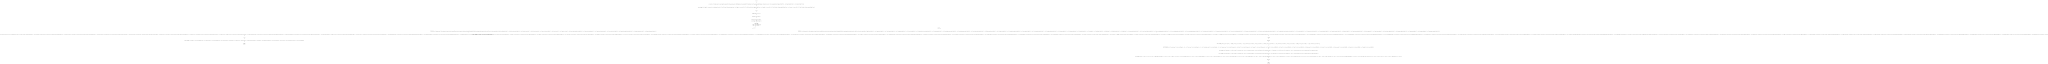

In [40]:
# Without optimization, the graph is quite big and contains a lot of
# information we do not need right now
lazy_report.popularity.show_graph(optimized=False)

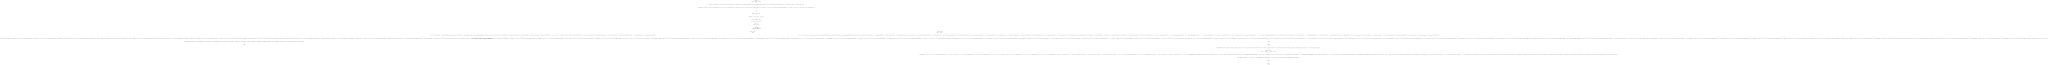

In [41]:
# The optimized graph shows us that polars ignores columns it does not need ("projection pushdown")
lazy_report.popularity.show_graph(optimized=True)

In [42]:
%%timeit
# It's important to call `to_string` here so that the query graph
# is executed
run_pipeline(raw_lazy).to_string()


86.4 ms ± 2.74 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [43]:
%%timeit
run_pipeline(raw).to_string()

84.6 ms ± 1.61 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Task 5: using dataframely schemas for raw data

In [ ]:
# TODO:
# - In `pipeline.schema.raw`, there are basic dataframely schemas for the raw data.
#   Import them and validate the data. 
# - Validation for `models` will fail. Use Schema.filter to to separate the good rows from the bad rows. Use `FailureInfo.details()` to inspect the failing rows.
# - Change the schema such that the raw data validation stops failing.
# - Remember the problem so we can fix it in preprocessing in the next step.

In [ ]:
from pipeline.schema.raw import RawModelsSchema, RawPoliciesSchema

RawModelsSchema.validate(raw.models, cast=True);

ValidationError: 1 rules failed validation:
 - 'primary_key' failed for 20 rows

In [55]:
good_models, failures = RawModelsSchema.filter(
    models
)

In [56]:
failures.counts()

{'primary_key': 20}

In [57]:
failures.details().sort("model")

model,segment,fuel_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,engine_type,make,max_power,max_torque,…,is_parking_camera|nullability,rear_brakes_type|nullability,displacement|nullability,cylinder|nullability,transmission_type|nullability,gear_box|nullability,steering_type|nullability,turning_radius|nullability,turning_radius|inf,turning_radius|nan,length|nullability,length|inf,length|nan,width|nullability,width|inf,width|nan,height|nullability,height|inf,height|nan,gross_weight|nullability,is_front_fog_lights|nullability,is_rear_window_wiper|nullability,is_rear_window_washer|nullability,is_rear_window_defogger|nullability,is_brake_assist|nullability,is_power_door_locks|nullability,is_central_locking|nullability,is_power_steering|nullability,is_driver_seat_height_adjustable|nullability,is_day_night_rear_view_mirror|nullability,is_ecw|nullability,is_speed_alert|nullability,ncap_rating|nullability,engine_type|nullability,make|nullability,max_power|nullability,max_torque|nullability
str,str,str,i64,str,str,str,str,str,str,i64,i64,str,i64,str,f64,f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,u64,str,str,…,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum,enum
"""M1107""","""Utility""","""Petrol""",1,"""No""","""Yes""","""No""","""Yes""","""Yes""","""Disc""",1498,4,"""Manual""",5,"""Electric""",4.9,401.2932,167.6312,155.617,1388,"""No""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""Yes""",5,"""2.0 L TDI CR""",4,"""118.375bhp@5999rpm""","""249.2Nm@4396rpm""",…,"""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid"""
"""M1107""","""Utility""","""Petrol""",1,"""No""","""Yes""","""No""","""Yes""","""Yes""","""Disc""",1498,4,"""Manual""",5,"""Electric""",4.9,401.2932,167.6312,155.617,1388,"""No""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""Yes""",5,"""2.0 L TDI CR""",4,"""118.375bhp@5999rpm""","""249.2Nm@4396rpm""",…,"""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid"""
"""M254""","""Utility""","""CNG""",1,"""No""","""Yes""","""No""","""Yes""","""No""","""Drum""",1076,3,"""Manual""",5,"""Power""",4.56,328.0476,154.8038,143.1866,1601,"""No""","""No""","""No""","""No""","""Yes""","""No""","""Yes""","""Yes""","""No""","""No""","""No""","""Yes""",4,"""2.0 L e:HEV""",0,"""71.8125bhp@6000rpm""","""90.3Nm@4332rpm""",…,"""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid""","""valid

In [58]:
good_models, failures = RawModelsSchema.filter(
    models.unique()
)

In [54]:
RawPoliciesSchema.validate(policies, cast=True);

In [ ]:
# The raw table has a few models with two rows
raw.models.group_by("model").len().filter(pl.col("len") > 1).collect()

model,len
str,u32
"""M937""",2
"""M477""",2
"""M676""",2
"""M964""",2
"""M946""",2
"""M254""",2
"""M40""",2
"""M324""",2
"""M1107""",2


In [ ]:
# The lines are truly duplicate, i.e. all other columns are also the same
# so a pragmatic solution is to drop them.
raw.models.unique().group_by("model").len().filter(pl.col("len") > 1).collect()

model,len
str,u32


# Task 6: using dataframely schemas for preprocessed data

In [ ]:
# TODO:
# - In `pipeline.schema.preprocessed`, there are similar schema definitions for our preprocessed data.
#   Extend the schemas such that they catch the mm-vs-cm issue we encountered when calculcating the car volume above.
# - Verify that validating the preprocessed data fails, and extend the preprocessing code such that validation succeeds again.
# - Fix the preprocessing code for `models` to deal with the validation problem from the last step.
# - Add `Schema.validate(cast=True, eager=False)` calls to the preprocessing methods and adapt the type hints

# Task 7: Using dataframely schemas for report outputs

In [ ]:
# TODO:
# - Add dataframely schemas for the tables we create in `report.py`. The schemas go in `pipeline/schema/report.py`
# - Extend the functions with the right type hints and add calls to `.validate`

# Task 8: Using dataframely to write a test for our report

In [ ]:
# TODO:
# - Fill in the code in `tests/test_report.py`. Execute the test via `pixi run pytest tests/test_report.py`